In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import statsmodels as stat
import datetime as dt

import missingno as msno

In [2]:
data_model1=  pd.read_csv("data_model.csv",sep=';')

In [3]:
data_model1.head()

,Age,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,SiteEnergyUseWN(kBtu),TotalGHGEmissions,...,LargestPropertyUseType_Refrigerated Warehouse,LargestPropertyUseType_Residence Hall/Dormitory,LargestPropertyUseType_Retail Store,LargestPropertyUseType_Senior Care Community,LargestPropertyUseType_Supermarket/Grocery Store,LargestPropertyUseType_Wholesale Club/Supercenter,LargestPropertyUseType_Worship Facility,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage
0,89,47.61220,-122.33799,1.0,12,0,88434,60.0,7456910.0,249.98,...,0,0,0,0,0,0,0,1,1,1
1,20,47.61317,-122.33393,1.0,11,15064,88502,61.0,8664479.0,295.86,...,0,0,0,0,0,0,0,0,1,1
2,47,47.61393,-122.33810,1.0,41,196718,759392,43.0,73937112.0,2089.28,...,0,0,0,0,0,0,0,1,1,1
3,90,47.61412,-122.33664,1.0,10,0,61320,56.0,6946800.5,286.43,...,0,0,0,0,0,0,0,1,1,1
4,36,47.61375,-122.34047,1.0,18,62000,113580,75.0,14656503.0,505.01,...,0,0,0,0,0,0,0,0,1,1


In [4]:
data_model1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 35 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Age                                                           872 non-null    int64  
 1   Latitude                                                      872 non-null    float64
 2   Longitude                                                     872 non-null    float64
 3   NumberofBuildings                                             872 non-null    float64
 4   NumberofFloors                                                872 non-null    int64  
 5   PropertyGFAParking                                            872 non-null    int64  
 6   PropertyGFABuilding(s)                                        872 non-null    int64  
 7   ENERGYSTARScore                                               872 non-n

# Normalisation des données:

In [5]:
X = data_model1.values

In [6]:
from sklearn import preprocessing
std_scale = preprocessing.StandardScaler().fit(X) 
X_std = std_scale.transform(X)

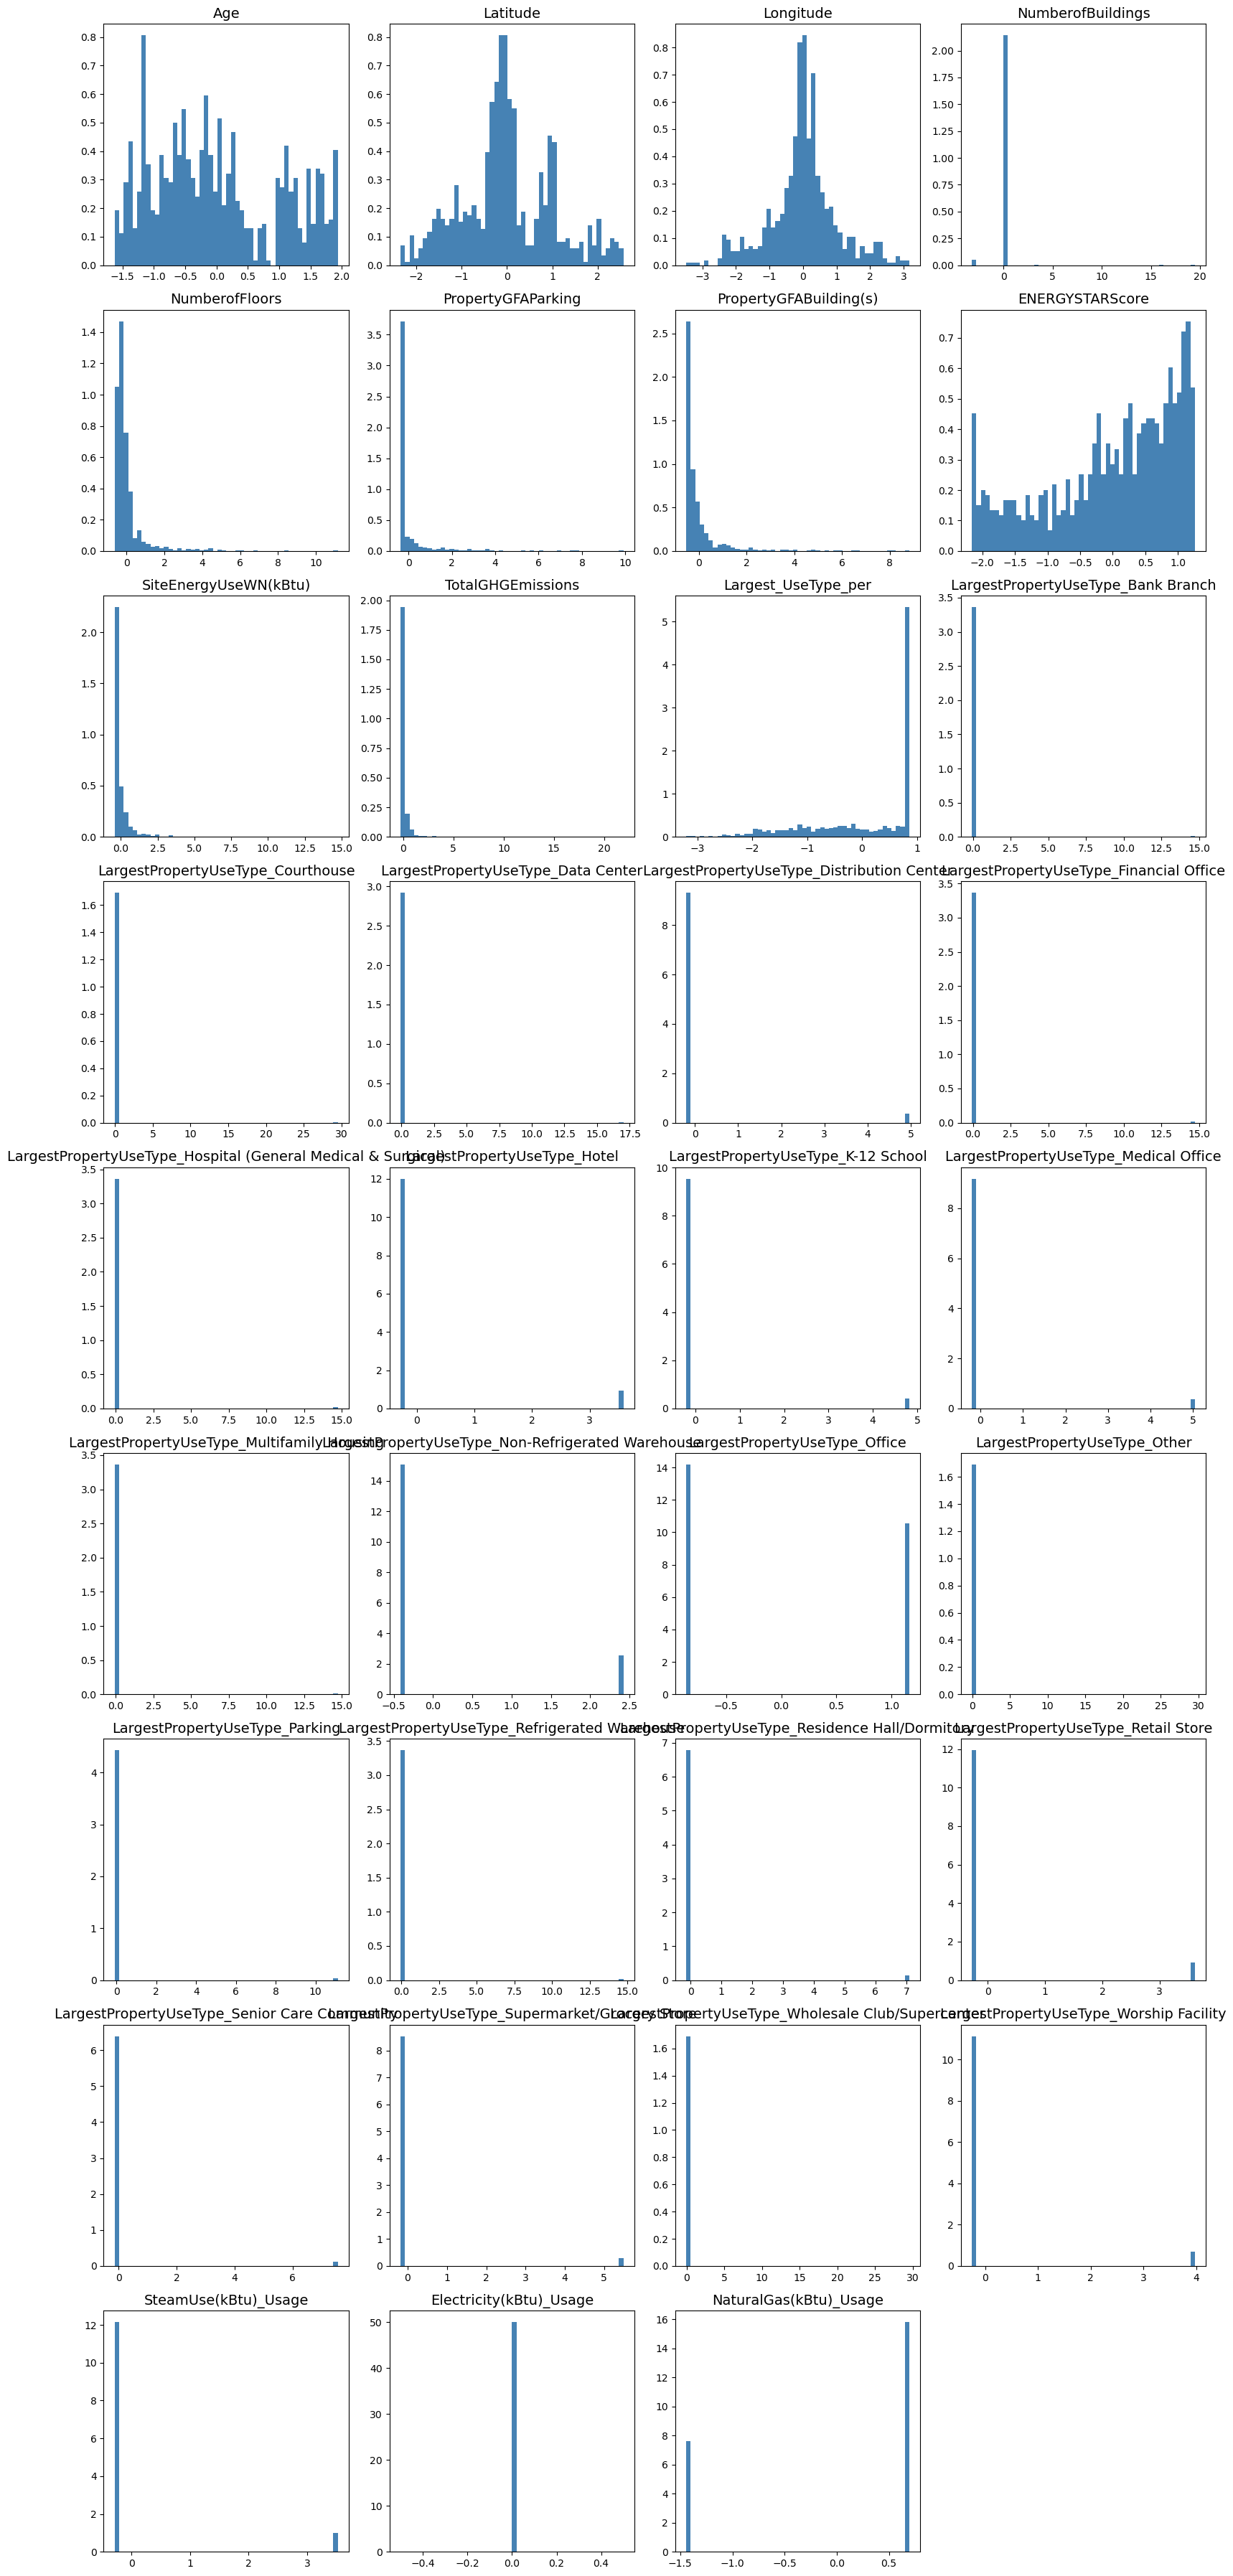

In [7]:
import math

num_features = X_std.shape[1] 
num_rows = math.ceil(num_features / 4) 
fig = plt.figure(figsize=(16, 4 * num_rows))

for feat_idx in range(num_features):
    ax = fig.add_subplot(num_rows, 4, (feat_idx+1)) 
    h = ax.hist(X_std[:, feat_idx], bins=50, color='steelblue', density=True, edgecolor='none') 
    ax.set_title(data_model1.columns[feat_idx], fontsize=14)

plt.tight_layout() 
plt.show()

In [8]:
df_normalized = pd.DataFrame(data=X_std, columns=data_model1.columns)

In [9]:
df_normalized

,Age,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,SiteEnergyUseWN(kBtu),TotalGHGEmissions,...,LargestPropertyUseType_Refrigerated Warehouse,LargestPropertyUseType_Residence Hall/Dormitory,LargestPropertyUseType_Retail Store,LargestPropertyUseType_Senior Care Community,LargestPropertyUseType_Supermarket/Grocery Store,LargestPropertyUseType_Wholesale Club/Supercenter,LargestPropertyUseType_Worship Facility,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage
0,1.099693,-0.095731,-0.201003,0.026028,0.803459,-0.363465,-0.136811,-0.121961,-0.032605,0.175930,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,3.523547,0.0,0.693163
1,-1.035256,-0.074500,-0.020387,0.026028,0.684428,-0.061577,-0.136448,-0.087398,0.029276,0.258695,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,-0.283805,0.0,0.693163
2,-0.199841,-0.057865,-0.205897,0.026028,4.255358,3.578844,3.444459,-0.709530,3.374125,3.493928,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,3.523547,0.0,0.693163
3,1.130635,-0.053706,-0.140946,0.026028,0.565397,-0.363465,-0.281534,-0.260213,-0.058746,0.241684,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,3.523547,0.0,0.693163
4,-0.540195,-0.061805,-0.311330,0.026028,1.517645,0.879040,-0.002593,0.396482,0.336333,0.635991,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,-0.283805,0.0,0.693163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,-1.623141,0.132559,-0.279745,0.026028,0.803459,2.967411,1.084179,1.191429,0.323672,0.089593,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,-0.283805,0.0,0.693163
868,-1.592199,0.129933,-0.019052,0.026028,0.922490,3.597702,1.200799,1.191429,0.304595,0.167235,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,-0.283805,0.0,0.693163
869,-1.592199,0.835816,-0.616065,0.026028,-0.148789,0.468993,-0.153625,0.292794,-0.105091,-0.038667,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,-0.283805,0.0,0.693163
870,0.233337,-1.583009,0.698965,0.026028,-0.505882,-0.278855,-0.353361,-0.916908,-0.200394,0.009462,...,-0.067884,-0.141007,-0.276664,-0.132299,-0.182141,-0.033884,-0.251823,-0.283805,0.0,0.693163


# Les fonctions utilisées :

# Creer les (X,Y Train,Test)

In [10]:
def prepare_data(df, target_col, cols_to_drop, test_size=0.3, random_state=42):
    from sklearn.model_selection import train_test_split
    X = df.drop(cols_to_drop, axis=1)
    Y = df[target_col]
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=random_state)
    return X_train, X_test, Y_train, Y_test

# Naive (DummyRegressor) ¶

In [11]:
from sklearn.model_selection import ParameterGrid, cross_validate, KFold
from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

def evaluate_dummy_regressor(X_train, X_test, Y_train, Y_test):
    # On définit les métriques
    scoring = {'R2': make_scorer(r2_score), 'RMSE': make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred))), 'MAE': make_scorer(mean_absolute_error)}

    strategies = {
        'mean': {},
        'quantile': {'quantile': [0, 0.25, 0.5, 0.75, 1]},
    }

    # Liste pour stocker les résultats
    results = []

    # Boucle sur les nombres de splits
    for n_splits in [5, 10]:
        # On définit les KFold pour la validation croisée
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

        # Pour chaque stratégie
        for strategy, params in strategies.items():

            # Générer toutes les combinaisons de paramètres
            param_grid = ParameterGrid(params)

            for param_combination in param_grid:

                # Créer et adapter le modèle pour chaque combinaison de paramètres
                dummy = DummyRegressor(strategy=strategy, **param_combination)
                scores = cross_validate(dummy, X_train, Y_train, cv=kf, scoring=scoring, return_train_score=True)

                # Enregistrer les scores et les paramètres pour chaque nombre de folds
                for fold in range(kf.get_n_splits()):
                    results.append({
                        'Folds': str(n_splits),
                        'strategy': strategy,
                        'params': param_combination,
                        'R2': scores['test_R2'][fold],
                        'RMSE': scores['test_RMSE'][fold],
                        'MAE': scores['test_MAE'][fold]
                    })

    # Convertir les résultats en DataFrame
    results_df = pd.DataFrame(results)

    # Extraire les valeurs des paramètres
    results_df['param_value'] = results_df['params'].apply(lambda x: list(x.values())[0] if x else 'None')

    # Calculer la moyenne des scores pour chaque combinaison de paramètres
    mean_scores = results_df.groupby(['Folds', 'strategy', 'param_value']).mean(numeric_only=True).reset_index()

    # Ajouter un classement en fonction de R2, RMSE et MAE
    mean_scores['R2_rank'] = mean_scores['R2'].rank(method='min', ascending=False).astype(int)
    mean_scores['RMSE_rank'] = mean_scores['RMSE'].rank(method='min').astype(int)
    mean_scores['MAE_rank'] = mean_scores['MAE'].rank(method='min').astype(int)

    # Réorganiser les lignes en fonction de R2
    mean_scores = mean_scores.sort_values(by='R2_rank')

    # Réinitialiser l'index du DataFrame
    mean_scores = mean_scores.reset_index(drop=True)

    # Calculer la mesure agrégée des classements
    mean_scores['Aggregate_rank'] = mean_scores[['R2_rank', 'RMSE_rank', 'MAE_rank']].mean(axis=1)
    mean_scores = mean_scores.sort_values(by='Aggregate_rank')
    mean_scores = mean_scores.reset_index(drop=True)
    
    # Calculer le classement final
    mean_scores['Rank_final'] = mean_scores['Aggregate_rank'].rank(method='min', ascending=True).astype(int)
    display(mean_scores)
    
    best_row = mean_scores.loc[mean_scores['Rank_final'] == 1]
    best_strategy = best_row['strategy'].values[0]
    best_param_value = best_row['param_value'].values[0]
    best_params = {best_strategy: best_param_value} if best_param_value != 'None' else {}

    best_model = DummyRegressor(strategy=best_strategy, **best_params)
    best_model.fit(X_train, Y_train)

    y_pred = best_model.predict(X_test)

    scores = pd.DataFrame({
        'Strategy': [best_strategy],
        'Parameter Value': [best_param_value],
        'R2_Test': [r2_score(Y_test, y_pred)],
        'RMSE_Test': [np.sqrt(mean_squared_error(Y_test, y_pred))],
        'MAE_Test': [mean_absolute_error(Y_test, y_pred)]
    })

    scores.index = ['Régréssion Dummy']
    return scores

# Regression Lineaire: Lasso,Ridge et Elasticnet

In [12]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import ParameterGrid
import pandas as pd
import numpy as np

def evaluate_linear_regressor(X_train, X_test, Y_train, Y_test, regressor='ridge'):
    scoring = {'R2': make_scorer(r2_score), 'RMSE': make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred))), 'MAE': make_scorer(mean_absolute_error)}
    kfolds = [KFold(n_splits=n_splits, shuffle=True, random_state=42) for n_splits in [5, 10]]
    alphas = np.logspace(-4, 4, 10)  
    l1_ratios = np.geomspace(start=1e-10, stop=1, num=10)  
    results = []

    param_grid = {'alpha': alphas}
    model_class = {'ridge': Ridge, 'lasso': Lasso}.get(regressor, None)

    if regressor == 'elasticnet':
        model_class = ElasticNet
        param_grid['l1_ratio'] = l1_ratios

    if model_class is None:
        raise ValueError(f"Invalid regressor: {regressor}. Must be 'ridge', 'lasso', or 'elasticnet'.")

    for params in ParameterGrid(param_grid):
        model = model_class(**params, max_iter=1000000)
        pipeline = make_pipeline(StandardScaler(), model)
        for kf in kfolds:
            scores = cross_validate(pipeline, X_train, Y_train, cv=kf, scoring=scoring, return_train_score=True)
            for fold in range(kf.get_n_splits()):
                result = {
                    'Folds': kf.get_n_splits(),
                    'R2': scores['test_R2'][fold],
                    'RMSE': scores['test_RMSE'][fold],
                    'MAE': scores['test_MAE'][fold]
                }
                result.update(params)
                results.append(result)

    results_df = pd.DataFrame(results)
    group_cols = ['Folds'] + list(param_grid.keys())
    mean_scores = results_df.groupby(group_cols).mean(numeric_only=True).reset_index()
    mean_scores['R2_rank'] = mean_scores['R2'].rank(method='min', ascending=False).astype(int)
    mean_scores['RMSE_rank'] = mean_scores['RMSE'].rank(method='min').astype(int)
    mean_scores['MAE_rank'] = mean_scores['MAE'].rank(method='min').astype(int)
    mean_scores['Aggregate_rank'] = mean_scores[['R2_rank', 'RMSE_rank', 'MAE_rank']].mean(axis=1)
    mean_scores = mean_scores.sort_values(by='Aggregate_rank').reset_index(drop=True)
    mean_scores['Rank_final'] = mean_scores['Aggregate_rank'].rank(method='min', ascending=True).astype(int)
    display(mean_scores.head(10))

    best_params = mean_scores.loc[mean_scores['Rank_final'] == 1, list(param_grid.keys())].to_dict('records')[0]
    best_model = make_pipeline(StandardScaler(), model_class(**best_params, max_iter=100000))
    best_model.fit(X_train, Y_train)

    y_pred = best_model.predict(X_test)

    scores = {
        'R2_Test': r2_score(Y_test, y_pred),
        'RMSE_Test': np.sqrt(mean_squared_error(Y_test, y_pred)),
        'MAE_Test': mean_absolute_error(Y_test, y_pred)
    }
    scores.update(best_params)
    columns_order = list(best_params.keys()) + ['R2_Test', 'RMSE_Test', 'MAE_Test']
    scores_df = pd.DataFrame([scores], columns=columns_order, index=[f'Régression {regressor.capitalize()}'])
    return scores_df

# Non lineaire : Gradient Bosting

In [13]:
!pip install xgboost

In [14]:
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterGrid, cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

def evaluate_xgb_regressor(X_train, X_test, Y_train, Y_test):
    scoring = {'R2': make_scorer(r2_score), 'RMSE': make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred))), 'MAE': make_scorer(mean_absolute_error)}

    n_estimators_choices = np.linspace(100, 500, 5, dtype=int)
    learning_rate_choices = np.linspace(0.01, 0.5, 5)

    hyperparameters = {
        'n_estimators': n_estimators_choices,
        'learning_rate': learning_rate_choices,
    }

    results = []

    for n_splits in [5, 10]:
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

        param_grid = ParameterGrid(hyperparameters)

        for param_combination in param_grid:
            xgb = XGBRegressor(**param_combination, n_jobs = 12)
            scores = cross_validate(xgb, X_train, Y_train, cv=kf, scoring=scoring, return_train_score=True)

            for fold in range(kf.get_n_splits()):
                results.append({
                    'Folds': str(n_splits),
                    'params': param_combination,
                    'R2': scores['test_R2'][fold],
                    'RMSE': scores['test_RMSE'][fold],
                    'MAE': scores['test_MAE'][fold]
                })

    results_df = pd.DataFrame(results)

    results_df['n_estimators'] = results_df['params'].apply(lambda x: x['n_estimators'])
    results_df['learning_rate'] = results_df['params'].apply(lambda x: x['learning_rate'])

    mean_scores = results_df.groupby(['Folds', 'n_estimators', 'learning_rate']).mean(numeric_only=True).reset_index()

    mean_scores['R2_rank'] = mean_scores['R2'].rank(method='min', ascending=False).astype(int)
    mean_scores['RMSE_rank'] = mean_scores['RMSE'].rank(method='min').astype(int)
    mean_scores['MAE_rank'] = mean_scores['MAE'].rank(method='min').astype(int)

    mean_scores = mean_scores.sort_values(by='R2_rank')
    mean_scores = mean_scores.reset_index(drop=True)

    mean_scores['Aggregate_rank'] = mean_scores[['R2_rank', 'RMSE_rank', 'MAE_rank']].mean(axis=1)
    mean_scores = mean_scores.sort_values(by='Aggregate_rank')
    mean_scores = mean_scores.reset_index(drop=True)

    mean_scores['Rank_final'] = mean_scores['Aggregate_rank'].rank(method='min').astype(int)
    display(mean_scores.head(10))

    best_row = mean_scores.loc[mean_scores['Rank_final'] == 1]
    best_n_estimators = best_row['n_estimators'].values[0]
    best_learning_rate = best_row['learning_rate'].values[0]
    best_params = {'n_estimators': best_n_estimators, 'learning_rate': best_learning_rate}

    best_model = XGBRegressor(**best_params, n_jobs = 12)
    best_model.fit(X_train, Y_train)

    y_pred = best_model.predict(X_test)

    scores = pd.DataFrame({
        'n_estimators': [best_n_estimators],
        'learning_rate': [best_learning_rate],
        'R2_Test': [r2_score(Y_test, y_pred)],
        'RMSE_Test': [np.sqrt(mean_squared_error(Y_test, y_pred))],
        'MAE_Test': [mean_absolute_error(Y_test, y_pred)]
    })

    scores.index = ['Régression XGBoost']
    return scores

# Forêt Aléatoire:

In [15]:
from sklearn.model_selection import ParameterGrid, cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

def evaluate_random_forest(X_train, X_test, Y_train, Y_test):
    # Définir les métriques
    scoring = {'R2': make_scorer(r2_score), 'RMSE': make_scorer(lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred))), 'MAE': make_scorer(mean_absolute_error)}

    # Définir les hyperparamètres à tester
    
    n_estimators_choices = np.linspace(100, 500, 5, dtype=int)
    max_depth_choices = np.linspace(1, 20, 5, dtype=int)

    param_grid = {
        'n_estimators': n_estimators_choices,
        'max_depth': max_depth_choices,
    }
    

    # Liste pour stocker les résultats
    results = []

    # Boucle sur les nombres de splits
    for n_splits in [5, 10]:
        # Définir les KFold pour la validation croisée
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

        # Générer toutes les combinaisons de paramètres
        param_combinations = list(ParameterGrid(param_grid))

        # Pour chaque combinaison de paramètres
        for param_combination in param_combinations:
            n_estimators = int(param_combination['n_estimators'])
            max_depth = None if param_combination['max_depth'] is None else int(param_combination['max_depth'])

            # Créer et adapter le modèle pour chaque combinaison de paramètres
            rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs = 12)
            scores = cross_validate(rf, X_train, Y_train, cv=kf, scoring=scoring, return_train_score=True)

            # Enregistrer les scores et les paramètres pour chaque nombre de folds
            for fold in range(kf.get_n_splits()):
                results.append({
                    'Folds': str(n_splits),
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'R2': scores['test_R2'][fold],
                    'RMSE': scores['test_RMSE'][fold],
                    'MAE': scores['test_MAE'][fold]
                })

    # Convertir les résultats en DataFrame
    results_df = pd.DataFrame(results)

    # Calculer la moyenne des scores pour chaque combinaison de paramètres
    mean_scores = results_df.groupby(['Folds', 'n_estimators', 'max_depth']).mean(numeric_only=True).reset_index()

    # Ajouter un classement en fonction de R2, RMSE et MAE
    mean_scores['R2_rank'] = mean_scores['R2'].rank(method='min', ascending=False).astype(int)
    mean_scores['RMSE_rank'] = mean_scores['RMSE'].rank(method='min').astype(int)
    mean_scores['MAE_rank'] = mean_scores['MAE'].rank(method='min').astype(int)

    # Réorganiser les lignes en fonction de R2
    mean_scores = mean_scores.sort_values(by='R2_rank')

    # Réinitialiser l'index du DataFrame
    mean_scores = mean_scores.reset_index(drop=True)

    # Calculer la mesure agrégée des classements
    mean_scores['Aggregate_rank'] = mean_scores[['R2_rank', 'RMSE_rank', 'MAE_rank']].mean(axis=1)
    mean_scores = mean_scores.sort_values(by='Aggregate_rank')
    mean_scores = mean_scores.reset_index(drop=True)
    
    # Calculer le classement final
    mean_scores['Rank_final'] = mean_scores['Aggregate_rank'].rank(method='min', ascending=True).astype(int)
    display(mean_scores.head(10))
    
    best_row = mean_scores.loc[mean_scores['Rank_final'] == 1]
    best_n_estimators = best_row['n_estimators'].values[0]
    best_max_depth = best_row['max_depth'].values[0]

    best_n_estimators = int(best_row['n_estimators'].values[0])
    best_max_depth = None if best_row['max_depth'].values[0] is None else int(best_row['max_depth'].values[0])

    best_model = RandomForestRegressor(n_estimators=best_n_estimators, max_depth=best_max_depth, random_state=42, n_jobs=12)

    best_model.fit(X_train, Y_train)

    y_pred = best_model.predict(X_test)

    scores = pd.DataFrame({
        'n_estimators': [best_n_estimators],
        'max_depth': [best_max_depth],
        'R2_Test': [r2_score(Y_test, y_pred)],
        'RMSE_Test': [np.sqrt(mean_squared_error(Y_test, y_pred))],
        'MAE_Test': [mean_absolute_error(Y_test, y_pred)]
    })

    scores.index = ['Régression Random Forest']
    return scores

# Prediction de l'energie consommée:SiteEnergyUseWN(kBtu) 

# Sans EnergyStarScore

In [16]:
X_train, X_test, Y_train, Y_test = prepare_data(df_normalized, target_col = 'SiteEnergyUseWN(kBtu)', cols_to_drop = ['TotalGHGEmissions', 'SiteEnergyUseWN(kBtu)', 'ENERGYSTARScore'])

# Approche Naive (DummyRegressor)

In [17]:
dummy_without_ENERGY = evaluate_dummy_regressor(X_train, X_test, Y_train, Y_test)

,Folds,strategy,param_value,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,quantile,0.75,-0.026007,0.818789,0.400363,3,1,5,3.000000,1
1,10,quantile,0.5,-0.125207,0.852867,0.330472,6,3,1,3.333333,2
2,5,quantile,0.75,-0.016612,0.889235,0.401391,1,5,6,4.000000,3
3,10,mean,None,-0.032627,0.820104,0.406751,4,2,9,5.000000,4
4,5,quantile,0.5,-0.098567,0.921358,0.330484,5,8,2,5.000000,4
5,10,quantile,0.25,-0.241963,0.883311,0.347813,8,4,4,5.333333,6
6,5,mean,None,-0.018676,0.889530,0.407544,2,6,10,6.000000,7
7,5,quantile,0.25,-0.182838,0.948566,0.347762,7,9,3,6.333333,8
8,10,quantile,0,-0.373908,0.915090,0.403007,10,7,8,8.333333,9
9,5,quantile,0,-0.276884,0.976994,0.402820,9,10,7,8.666667,10


In [18]:
dummy_without_ENERGY

,Strategy,Parameter Value,R2_Test,RMSE_Test,MAE_Test
Régréssion Dummy,quantile,0.75,-0.001119,1.09062,0.435321


# Approche Linéaire

# Régréssion Ridge

In [19]:
ridge_without_ENERGY = evaluate_linear_regressor(X_train, X_test, Y_train, Y_test, regressor='ridge')

,Folds,alpha,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,166.810054,0.385897,0.626021,0.231374,2,1,2,1.666667,1
1,10,21.544347,0.253571,0.647080,0.241190,5,3,3,3.666667,2
2,10,2.782559,0.226168,0.651234,0.244190,6,4,5,5.000000,3
3,5,166.810054,0.299643,0.708161,0.230941,4,10,1,5.000000,3
4,10,0.359381,0.222330,0.651818,0.244629,7,5,6,6.000000,5
5,10,1291.549665,0.444108,0.643431,0.274355,1,2,17,6.666667,6
6,10,0.046416,0.221828,0.651894,0.244686,8,6,7,7.000000,7
7,10,0.005995,0.221763,0.651904,0.244693,9,7,8,8.000000,8
8,5,21.544347,0.161904,0.724379,0.241355,12,11,4,9.000000,9
9,10,0.000774,0.221755,0.651905,0.244694,10,8,9,9.000000,9


In [20]:
ridge_without_ENERGY

,alpha,R2_Test,RMSE_Test,MAE_Test
Régression Ridge,166.810054,0.865307,0.40004,0.188754


# Regression Lasso

In [21]:
lasso_without_ENERGY = evaluate_linear_regressor(X_train, X_test, Y_train, Y_test, regressor='lasso')

,Folds,alpha,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,0.046416,0.299292,0.650233,0.237742,3,1,4,2.666667,1
1,10,0.005995,0.231202,0.652537,0.237226,4,4,2,3.333333,2
2,10,0.000774,0.222499,0.652093,0.243366,5,3,5,4.333333,3
3,10,0.359381,0.411403,0.660991,0.299815,1,5,9,5.000000,4
4,10,0.000100,0.221245,0.652014,0.244475,6,2,7,5.000000,4
5,5,0.005995,0.133021,0.732617,0.236709,8,8,1,5.666667,6
6,5,0.046416,0.185387,0.738575,0.237713,7,9,3,6.333333,7
7,5,0.000774,0.125987,0.730186,0.244451,9,7,6,7.333333,8
8,5,0.359381,0.338767,0.747565,0.302054,2,10,10,7.333333,8
9,5,0.000100,0.124598,0.730081,0.245882,10,6,8,8.000000,10


In [22]:
lasso_without_ENERGY

,alpha,R2_Test,RMSE_Test,MAE_Test
Régression Lasso,0.046416,0.878718,0.379602,0.200927


# ElasticNet à faire

In [23]:
elasticnet_without_ENERGY = evaluate_linear_regressor(X_train, X_test, Y_train, Y_test, regressor='elasticnet')

,Folds,alpha,l1_ratio,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,0.359381,5.994843e-03,0.405768,0.622355,0.230564,11,2,2,5.000000,1
1,10,0.359381,4.641589e-04,0.402864,0.623149,0.230957,12,3,10,8.333333,2
2,10,0.359381,3.593814e-05,0.402563,0.623239,0.230999,13,4,11,9.333333,3
3,10,0.359381,2.782559e-06,0.402540,0.623246,0.231002,14,5,12,10.333333,4
4,10,0.359381,7.742637e-02,0.420611,0.621104,0.238649,8,1,24,11.000000,5
5,10,0.359381,2.154435e-07,0.402538,0.623246,0.231003,15,6,13,11.333333,6
6,10,0.359381,1.668101e-08,0.402538,0.623246,0.231003,16,7,14,12.333333,7
7,10,0.359381,1.291550e-09,0.402538,0.623246,0.231003,17,8,15,13.333333,8
8,10,0.359381,1.000000e-10,0.402538,0.623246,0.231003,18,9,16,14.333333,9
9,10,0.046416,7.742637e-02,0.262320,0.646302,0.236845,39,17,19,25.000000,10


In [24]:
elasticnet_without_ENERGY

,alpha,l1_ratio,R2_Test,RMSE_Test,MAE_Test
Régression Elasticnet,0.359381,0.005995,0.852152,0.41912,0.192327


# Approche Non Lineaire

In [25]:
X_train, X_test, Y_train, Y_test = prepare_data(data_model1, target_col = 'SiteEnergyUseWN(kBtu)', cols_to_drop = ['TotalGHGEmissions', 'SiteEnergyUseWN(kBtu)', 'ENERGYSTARScore'])

# XGBRegressor

In [26]:
xgb_without_ENERGY = evaluate_xgb_regressor(X_train, X_test, Y_train, Y_test)

,Folds,n_estimators,learning_rate,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,300,0.0100,0.382160,1.318431e+07,4.148134e+06,3,3,2,2.666667,1
1,10,200,0.0100,0.429438,1.281980e+07,4.255061e+06,2,2,9,4.333333,2
2,10,100,0.2550,0.355553,1.329256e+07,4.252032e+06,4,4,8,5.333333,3
3,10,400,0.0100,0.351081,1.339275e+07,4.147603e+06,9,9,1,6.333333,4
4,10,200,0.2550,0.354819,1.329588e+07,4.264170e+06,5,5,10,6.666667,5
5,10,300,0.2550,0.354778,1.329610e+07,4.265129e+06,6,6,12,8.000000,6
6,10,400,0.2550,0.354768,1.329618e+07,4.265235e+06,7,8,13,9.333333,7
7,10,500,0.0100,0.344490,1.343508e+07,4.150056e+06,10,15,3,9.333333,7
8,10,500,0.2550,0.354768,1.329618e+07,4.265238e+06,8,7,14,9.666667,9
9,10,100,0.1325,0.328030,1.350828e+07,4.222920e+06,16,21,4,13.666667,10


In [27]:
xgb_without_ENERGY

,n_estimators,learning_rate,R2_Test,RMSE_Test,MAE_Test
Régression XGBoost,300,0.01,0.287006,1.796089e+07,4.914028e+06


# Forêt Aleatoire

In [28]:
randomForest_without_ENERGY = evaluate_random_forest(X_train, X_test, Y_train, Y_test)

,Folds,n_estimators,max_depth,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,100,15,0.542228,1.134219e+07,3.696938e+06,5,4,14,7.666667,1
1,10,200,10,0.544332,1.134654e+07,3.704397e+06,4,5,20,9.666667,2
2,10,200,20,0.542068,1.138884e+07,3.700471e+06,7,7,18,10.666667,3
3,10,100,5,0.564356,1.114044e+07,3.797969e+06,1,1,31,11.000000,4
4,10,200,5,0.554302,1.126149e+07,3.815554e+06,2,2,32,12.000000,5
5,10,400,15,0.541041,1.140255e+07,3.696963e+06,10,11,15,12.000000,5
6,10,200,15,0.542171,1.139202e+07,3.709363e+06,6,8,23,12.333333,7
7,10,300,5,0.547575,1.133646e+07,3.828889e+06,3,3,33,13.000000,8
8,10,300,15,0.541950,1.141171e+07,3.701004e+06,8,12,19,13.000000,8
9,10,100,20,0.541491,1.135220e+07,3.709914e+06,9,6,24,13.000000,8


In [29]:
randomForest_without_ENERGY 

,n_estimators,max_depth,R2_Test,RMSE_Test,MAE_Test
Régression Random Forest,100,15,0.705375,1.154570e+07,4.176735e+06


# Avec EnergyStar

In [30]:
X_train, X_test, Y_train, Y_test = prepare_data(df_normalized, target_col = 'SiteEnergyUseWN(kBtu)', cols_to_drop = ['TotalGHGEmissions', 'SiteEnergyUseWN(kBtu)'])

#  Approche Naive (DummyRegressor)

In [31]:
dummy_with_ENERGY = evaluate_dummy_regressor(X_train, X_test, Y_train, Y_test)

,Folds,strategy,param_value,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,quantile,0.75,-0.026007,0.818789,0.400363,3,1,5,3.000000,1
1,10,quantile,0.5,-0.125207,0.852867,0.330472,6,3,1,3.333333,2
2,5,quantile,0.75,-0.016612,0.889235,0.401391,1,5,6,4.000000,3
3,10,mean,None,-0.032627,0.820104,0.406751,4,2,9,5.000000,4
4,5,quantile,0.5,-0.098567,0.921358,0.330484,5,8,2,5.000000,4
5,10,quantile,0.25,-0.241963,0.883311,0.347813,8,4,4,5.333333,6
6,5,mean,None,-0.018676,0.889530,0.407544,2,6,10,6.000000,7
7,5,quantile,0.25,-0.182838,0.948566,0.347762,7,9,3,6.333333,8
8,10,quantile,0,-0.373908,0.915090,0.403007,10,7,8,8.333333,9
9,5,quantile,0,-0.276884,0.976994,0.402820,9,10,7,8.666667,10


In [32]:
dummy_with_ENERGY

,Strategy,Parameter Value,R2_Test,RMSE_Test,MAE_Test
Régréssion Dummy,quantile,0.75,-0.001119,1.09062,0.435321


# Approche Linéaire

# Ridge

In [33]:
ridge_with_ENERGY = evaluate_linear_regressor(X_train, X_test, Y_train, Y_test, regressor='ridge')

,Folds,alpha,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,166.810054,0.412715,0.613732,0.220565,2,1,2,1.666667,1
1,10,21.544347,0.286053,0.632819,0.232275,5,2,4,3.666667,2
2,10,2.782559,0.258840,0.636837,0.235872,6,3,5,4.666667,3
3,5,166.810054,0.321395,0.698955,0.220486,4,10,1,5.000000,4
4,10,0.359381,0.254982,0.637413,0.236404,7,4,6,5.666667,5
5,10,0.046416,0.254477,0.637489,0.236473,8,5,7,6.666667,6
6,10,0.005995,0.254411,0.637498,0.236482,9,6,8,7.666667,7
7,5,21.544347,0.189352,0.712219,0.232117,12,11,3,8.666667,8
8,10,0.000774,0.254403,0.637500,0.236483,10,7,9,8.666667,8
9,10,1291.549665,0.450637,0.640768,0.272387,1,9,17,9.000000,10


In [34]:
ridge_with_ENERGY

,alpha,R2_Test,RMSE_Test,MAE_Test
Régression Ridge,166.810054,0.871695,0.390438,0.175417


# Lasso

In [35]:
lasso_with_ENERGY = evaluate_linear_regressor(X_train, X_test, Y_train, Y_test, regressor='lasso')

,Folds,alpha,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,0.046416,0.327208,0.639028,0.224901,3,3,1,2.333333,1
1,10,0.000774,0.255852,0.637565,0.235096,5,1,5,3.666667,2
2,10,0.005995,0.265484,0.639196,0.226946,4,4,3,3.666667,2
3,10,0.359381,0.411403,0.660991,0.299815,1,5,9,5.000000,4
4,10,0.000100,0.254125,0.637621,0.236437,6,2,7,5.000000,4
5,5,0.046416,0.208048,0.730050,0.226177,7,9,2,6.000000,6
6,5,0.005995,0.164594,0.718632,0.226988,8,8,4,6.666667,7
7,5,0.000774,0.154224,0.717484,0.236132,9,7,6,7.333333,8
8,5,0.359381,0.338767,0.747565,0.302054,2,10,10,7.333333,8
9,5,0.000100,0.152564,0.717429,0.237609,10,6,8,8.000000,10


In [36]:
lasso_with_ENERGY

,alpha,R2_Test,RMSE_Test,MAE_Test
Régression Lasso,0.046416,0.885896,0.368198,0.185407


# ElasticNet

In [37]:
elasticnet_with_ENERGY = evaluate_linear_regressor(X_train, X_test, Y_train, Y_test, regressor='elasticnet')

,Folds,alpha,l1_ratio,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,0.359381,5.994843e-03,0.431739,0.610306,0.219675,2,1,2,1.666667,1
1,10,0.359381,4.641589e-04,0.428434,0.611319,0.220280,10,2,3,5.000000,2
2,10,0.359381,3.593814e-05,0.428162,0.611402,0.220333,11,3,4,6.000000,3
3,10,0.359381,2.782559e-06,0.428141,0.611408,0.220337,12,4,5,7.000000,4
4,10,0.359381,2.154435e-07,0.428140,0.611409,0.220337,13,5,6,8.000000,5
5,10,0.359381,1.668101e-08,0.428139,0.611409,0.220337,14,6,7,9.000000,6
6,10,0.359381,1.291550e-09,0.428139,0.611409,0.220337,15,7,8,10.000000,7
7,10,0.359381,1.000000e-10,0.428139,0.611409,0.220337,16,8,9,11.000000,8
8,10,0.359381,7.742637e-02,0.441728,0.611778,0.229196,1,9,24,11.333333,9
9,10,0.046416,7.742637e-02,0.293732,0.634021,0.227212,38,18,22,26.000000,10


In [38]:
elasticnet_with_ENERGY

,alpha,l1_ratio,R2_Test,RMSE_Test,MAE_Test
Régression Elasticnet,0.359381,0.005995,0.858091,0.410615,0.177739


# Approche Non Lineaire

In [39]:
X_train, X_test, Y_train, Y_test = prepare_data(data_model1, target_col = 'SiteEnergyUseWN(kBtu)', cols_to_drop = ['TotalGHGEmissions', 'SiteEnergyUseWN(kBtu)'])

# XGBRegressor

In [40]:
xgb_with_ENERGY = evaluate_xgb_regressor(X_train, X_test, Y_train, Y_test)

,Folds,n_estimators,learning_rate,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,100,0.3775,0.446420,1.259303e+07,3.498745e+06,5,4,6,5.000000,1
1,10,500,0.3775,0.446417,1.259306e+07,3.499974e+06,6,5,10,7.000000,2
2,10,400,0.3775,0.446417,1.259307e+07,3.499974e+06,7,6,9,7.333333,3
3,10,200,0.3775,0.446417,1.259307e+07,3.499956e+06,8,8,7,7.666667,4
4,10,300,0.3775,0.446417,1.259307e+07,3.499974e+06,9,7,8,8.000000,5
5,10,100,0.1325,0.440534,1.268605e+07,3.479858e+06,11,13,1,8.333333,6
6,10,500,0.1325,0.439783,1.268382e+07,3.485278e+06,12,9,5,8.666667,7
7,10,400,0.1325,0.439767,1.268404e+07,3.485188e+06,13,10,4,9.000000,8
8,10,300,0.0100,0.466905,1.256368e+07,3.630280e+06,2,3,23,9.333333,9
9,10,300,0.1325,0.439731,1.268448e+07,3.484567e+06,14,11,3,9.333333,9


In [41]:
xgb_with_ENERGY

,n_estimators,learning_rate,R2_Test,RMSE_Test,MAE_Test
Régression XGBoost,100,0.3775,0.239338,1.855158e+07,4.346967e+06


# Forêt Aleatoire

In [42]:
randomForest_with_ENERGY = evaluate_random_forest(X_train, X_test, Y_train, Y_test)

,Folds,n_estimators,max_depth,R2,RMSE,MAE,R2_rank,RMSE_rank,MAE_rank,Aggregate_rank,Rank_final
0,10,100,15,0.601228,1.074959e+07,3.103447e+06,2,1,1,1.333333,1
1,10,300,15,0.597140,1.085910e+07,3.125748e+06,4,5,2,3.666667,2
2,10,100,10,0.604154,1.076245e+07,3.155603e+06,1,2,11,4.666667,3
3,10,100,20,0.596188,1.083949e+07,3.131767e+06,6,4,5,5.000000,4
4,10,200,15,0.596499,1.086654e+07,3.133221e+06,5,6,6,5.666667,5
5,10,200,10,0.597924,1.083814e+07,3.167827e+06,3,3,13,6.333333,6
6,10,400,20,0.591424,1.088820e+07,3.126249e+06,8,8,3,6.333333,6
7,10,400,15,0.587658,1.092102e+07,3.130731e+06,10,10,4,8.000000,8
8,10,300,10,0.591503,1.087577e+07,3.172189e+06,7,7,15,9.666667,9
9,10,200,20,0.590001,1.092198e+07,3.151178e+06,9,11,9,9.666667,9


In [43]:
randomForest_with_ENERGY

,n_estimators,max_depth,R2_Test,RMSE_Test,MAE_Test
Régression Random Forest,100,15,0.708355,1.148716e+07,3.480009e+06


In [44]:
# Quel est le meilleur modèle?

In [45]:
a_wo = dummy_without_ENERGY
a_wo = a_wo.rename(index={'Régréssion Dummy': 'Dummy (SANS ESS)'})
a_wo = a_wo.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
a_wo

,R2_Test,RMSE_Test,MAE_Test
Dummy (SANS ESS),-0.001119,1.09062,0.435321


In [46]:
b_wo = ridge_without_ENERGY
b_wo = b_wo.rename(index={'Régression Ridge': 'Ridge (SANS ESS)'})
b_wo = b_wo.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
b_wo

,R2_Test,RMSE_Test,MAE_Test
Ridge (SANS ESS),0.865307,0.40004,0.188754


In [47]:
c_wo = lasso_without_ENERGY
c_wo = c_wo.rename(index={'Régression Lasso': 'Lasso (SANS ESS)'})
c_wo = c_wo.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
c_wo

,R2_Test,RMSE_Test,MAE_Test
Lasso (SANS ESS),0.878718,0.379602,0.200927


In [48]:
f_wo = elasticnet_without_ENERGY
f_wo = f_wo.rename(index={'Régression Elasticnet': 'Elasticnet (SANS ESS)'})
f_wo = f_wo.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
f_wo

,R2_Test,RMSE_Test,MAE_Test
Elasticnet (SANS ESS),0.852152,0.41912,0.192327


In [49]:
d_wo = xgb_without_ENERGY
d_wo = d_wo.rename(index={'Régression XGBoost': 'XGBoost (SANS ESS)'})
d_wo = d_wo.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
d_wo

,R2_Test,RMSE_Test,MAE_Test
XGBoost (SANS ESS),0.287006,1.796089e+07,4.914028e+06


In [50]:
e_wo = randomForest_without_ENERGY
e_wo = e_wo.rename(index={'Régression Random Forest': 'Random Forest (SANS ESS)'})
e_wo = e_wo.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
e_wo

,R2_Test,RMSE_Test,MAE_Test
Random Forest (SANS ESS),0.705375,1.154570e+07,4.176735e+06


In [51]:
df_merged_wo = pd.concat([a_wo, b_wo,c_wo,f_wo,d_wo,e_wo])

df_merged_wo

,R2_Test,RMSE_Test,MAE_Test
Dummy (SANS ESS),-0.001119,1.090620e+00,4.353208e-01
Ridge (SANS ESS),0.865307,4.000399e-01,1.887535e-01
Lasso (SANS ESS),0.878718,3.796024e-01,2.009272e-01
Elasticnet (SANS ESS),0.852152,4.191199e-01,1.923270e-01
XGBoost (SANS ESS),0.287006,1.796089e+07,4.914028e+06
Random Forest (SANS ESS),0.705375,1.154570e+07,4.176735e+06


In [52]:
def highlight_max_min(df):
    # Définir une fonction pour appliquer le style CSS
    def apply_style(series):
        min_value = series.min()
        max_value = series.max()
        colors = []
        for val in series:
            if series.name == 'R2_Test':
                color = 'green' if val == max_value else 'crimson' if val == min_value else ''
            else:  # for 'RMSE_Test' and 'MAE_Test'
                color = 'green' if val == min_value else 'crimson' if val == max_value else ''
            colors.append(f'background-color: {color}' if color else '')
        return colors

    df_styled = df.style.apply(apply_style)
    
    return df_styled

df_merged_styled_wo = highlight_max_min(df_merged_wo)
df_merged_styled_wo


,R2_Test,RMSE_Test,MAE_Test
Dummy (SANS ESS),-0.001119,1.090620,0.435321
Ridge (SANS ESS),0.865307,0.400040,0.188754
Lasso (SANS ESS),0.878718,0.379602,0.200927
Elasticnet (SANS ESS),0.852152,0.419120,0.192327
XGBoost (SANS ESS),0.287006,17960893.979915,4914027.941133
Random Forest (SANS ESS),0.705375,11545696.535126,4176735.029357


In [53]:
a_w = dummy_with_ENERGY
a_w = a_w.rename(index={'Régréssion Dummy': 'Dummy (AVEC ESS)'})
a_w = a_w.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
a_w

,R2_Test,RMSE_Test,MAE_Test
Dummy (AVEC ESS),-0.001119,1.09062,0.435321


In [54]:
b_w = ridge_with_ENERGY
b_w = b_w.rename(index={'Régression Ridge': 'Ridge (AVEC ESS)'})
b_w = b_w.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
b_w

,R2_Test,RMSE_Test,MAE_Test
Ridge (AVEC ESS),0.871695,0.390438,0.175417


In [55]:
c_w = lasso_with_ENERGY
c_w = c_w.rename(index={'Régression Lasso': 'Lasso (AVEC ESS)'})
c_w = c_w.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
c_w

,R2_Test,RMSE_Test,MAE_Test
Lasso (AVEC ESS),0.885896,0.368198,0.185407


In [56]:
f_w = elasticnet_with_ENERGY
f_w = f_w.rename(index={'Régression Elasticnet': 'Elasticnet (AVEC ESS)'})
f_w = f_w.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
f_w

,R2_Test,RMSE_Test,MAE_Test
Elasticnet (AVEC ESS),0.858091,0.410615,0.177739


In [57]:
d_w = xgb_with_ENERGY 
d_w = d_w.rename(index={'Régression XGBoost': 'XGBoost (AVEC ESS)'})
d_w = d_w.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
d_w

,R2_Test,RMSE_Test,MAE_Test
XGBoost (AVEC ESS),0.239338,1.855158e+07,4.346967e+06


In [58]:
e_w = randomForest_with_ENERGY
e_w = e_w.rename(index={'Régression Random Forest': 'Random Forest (AVEC ESS)'})
e_w = e_w.loc[:, ['R2_Test', 'RMSE_Test', 'MAE_Test']]
e_w

,R2_Test,RMSE_Test,MAE_Test
Random Forest (AVEC ESS),0.708355,1.148716e+07,3.480009e+06


In [59]:
df_merged_w = pd.concat([a_w, b_w,c_w,f_w,d_w,e_w])

df_merged_w

,R2_Test,RMSE_Test,MAE_Test
Dummy (AVEC ESS),-0.001119,1.090620e+00,4.353208e-01
Ridge (AVEC ESS),0.871695,3.904377e-01,1.754171e-01
Lasso (AVEC ESS),0.885896,3.681982e-01,1.854071e-01
Elasticnet (AVEC ESS),0.858091,4.106152e-01,1.777393e-01
XGBoost (AVEC ESS),0.239338,1.855158e+07,4.346967e+06
Random Forest (AVEC ESS),0.708355,1.148716e+07,3.480009e+06


In [60]:
df_merged_styled_w = highlight_max_min(df_merged_w)
df_merged_styled_w

,R2_Test,RMSE_Test,MAE_Test
Dummy (AVEC ESS),-0.001119,1.090620,0.435321
Ridge (AVEC ESS),0.871695,0.390438,0.175417
Lasso (AVEC ESS),0.885896,0.368198,0.185407
Elasticnet (AVEC ESS),0.858091,0.410615,0.177739
XGBoost (AVEC ESS),0.239338,18551578.452391,4346966.548485
Random Forest (AVEC ESS),0.708355,11487156.340276,3480008.904319


In [61]:
!pip install shap

In [62]:
import shap

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.075e+15, tolerance: 2.135e+13


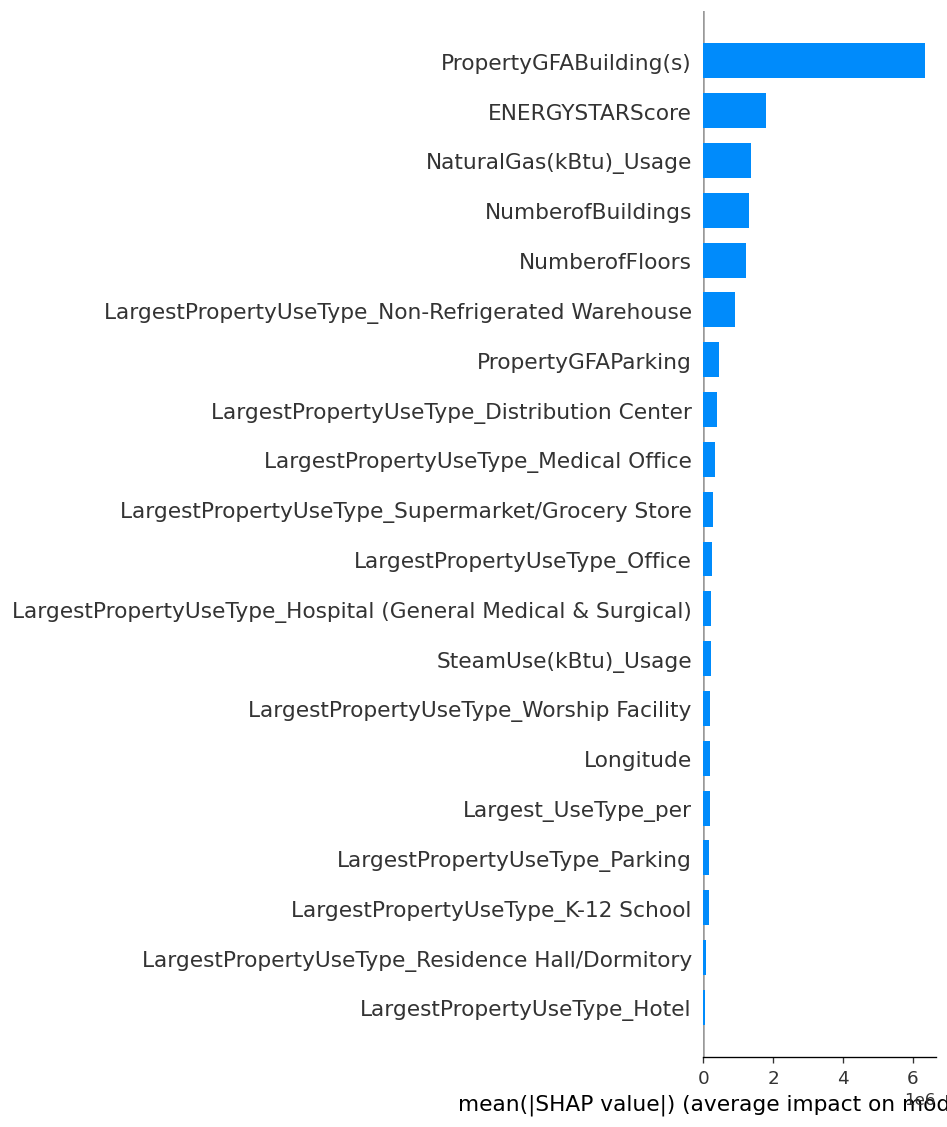

In [130]:
# L'importance des variables sera ici testé par la méthode de Shapley
# l'axe horizontal du graphique d'importance SHAP montre la moyenne des magnitudes des valeurs SHAP absolues
#pour chaque variable, ce qui permet d'évaluer l'impact moyen de chaque variable sur les prédictions du modèle.
#Plus la valeur est élevée, plus la variable a un impact important sur les prédictions du modèle
# Plus la valeur SHAP est importante, plus la variable affecte la valeur prédite. 

import shap
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt

# Entraîner le modèle Lasso
lasso_model = Lasso(alpha=0.046416)  # Remplacez alpha par la valeur que vous souhaitez
lasso_model.fit(X_train, Y_train)

# Calculer les valeurs SHAP
explainer = shap.LinearExplainer(lasso_model, X_train)
shap_values = explainer.shap_values(X_test)

# Afficher le graphique d'importance
plt.figure(figsize=(20, 10), dpi=120)
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()